### EDA

In [1]:
# Import Libraries

import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from scipy import stats
from IPython.display import display

plt.style.use("seaborn-v0_8")
sns.set_palette("Set2")

pd.set_option("display.max_columns", None) 

In [2]:
# Load Dataset

df = pd.read_csv("dataset.csv", sep=";")

print("Dataset Loaded Successfully!\n")

display(df.head()) 

Dataset Loaded Successfully!



,ID,age,systolic_bp,diastolic_bp,cholesterol,prognosis
0,0,77.196340,85.288742,80.021878,79.957109,retinopathy
1,1,63.529850,99.379736,84.852361,110.382411,retinopathy
2,2,69.003986,111.349455,109.850616,100.828246,retinopathy
3,3,82.638210,95.056128,79.666851,87.066303,retinopathy
4,4,78.346286,109.154591,90.713220,92.511770,retinopathy


In [3]:
# Dataset Overview

overview = pd.DataFrame({

    "Attribute":[

        "Number of Rows",
        "Number of Columns",
        "Numerical Features",
        "Categorical Features",
        "Missing Values",
        "Duplicate Records",
        "Memory Usage (KB)"

    ],

    "Value":[

        df.shape[0],

        df.shape[1],

        len(df.select_dtypes(include=np.number).columns),

        len(df.select_dtypes(exclude=np.number).columns),

        df.isnull().sum().sum(),

        df.duplicated().sum(),

        round(df.memory_usage().sum()/1024,2)

    ]

})

display(overview) 

,Attribute,Value
0,Number of Rows,6000.00
1,Number of Columns,6.00
2,Numerical Features,5.00
3,Categorical Features,1.00
4,Missing Values,0.00
5,Duplicate Records,0.00
6,Memory Usage (KB),281.38


In [4]:
# Dataset Preview

print("First Five Records")

display(df.head())

print("\nLast Five Records")

display(df.tail()) 

First Five Records


,ID,age,systolic_bp,diastolic_bp,cholesterol,prognosis
0,0,77.196340,85.288742,80.021878,79.957109,retinopathy
1,1,63.529850,99.379736,84.852361,110.382411,retinopathy
2,2,69.003986,111.349455,109.850616,100.828246,retinopathy
3,3,82.638210,95.056128,79.666851,87.066303,retinopathy
4,4,78.346286,109.154591,90.713220,92.511770,retinopathy



Last Five Records


,ID,age,systolic_bp,diastolic_bp,cholesterol,prognosis
5995,5995,49.611850,94.857639,86.615671,107.643986,no_retinopathy
5996,5996,63.099686,100.039527,93.515186,104.971404,retinopathy
5997,5997,55.562243,98.421446,102.697875,120.875951,retinopathy
5998,5998,63.468956,106.809289,88.060631,106.052213,retinopathy
5999,5999,62.506825,96.900784,86.878033,108.625436,no_retinopathy


In [5]:
# Random Sample

display(df.sample(10, random_state=42)) 

,ID,age,systolic_bp,diastolic_bp,cholesterol,prognosis
1782,1782,47.560989,101.621771,86.386967,106.609386,no_retinopathy
3917,3917,56.660791,118.134570,112.216252,114.815664,retinopathy
221,221,57.106537,102.763612,83.166657,86.887754,no_retinopathy
2135,2135,55.154948,110.019211,84.083581,95.115501,no_retinopathy
5224,5224,59.979271,104.991782,94.383732,109.430576,no_retinopathy
1168,1168,62.091636,90.205538,87.800483,94.065764,no_retinopathy
879,879,46.433728,107.961089,90.354178,105.863122,no_retinopathy
156,156,70.477432,106.001733,86.459429,107.178824,retinopathy
1657,1657,52.679326,88.869487,88.912647,99.197037,no_retinopathy
323,323,52.829565,88.675297,85.159000,103.180267,retinopathy


In [6]:
# Dataset Information

df.info() 

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6000 entries, 0 to 5999
Data columns (total 6 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   ID            6000 non-null   int64  
 1   age           6000 non-null   float64
 2   systolic_bp   6000 non-null   float64
 3   diastolic_bp  6000 non-null   float64
 4   cholesterol   6000 non-null   float64
 5   prognosis     6000 non-null   object 
dtypes: float64(4), int64(1), object(1)
memory usage: 281.4+ KB


In [7]:
# Data Types

datatype = pd.DataFrame({

    "Feature":df.columns,

    "Data Type":df.dtypes.values

})

display(datatype) 

,Feature,Data Type
0,ID,int64
1,age,float64
2,systolic_bp,float64
3,diastolic_bp,float64
4,cholesterol,float64
5,prognosis,object


In [8]:
# Column Names

print("Column Names:\n")

for column in df.columns:
    print(column) 

Column Names:

ID
age
systolic_bp
diastolic_bp
cholesterol
prognosis


,Missing Values,Percentage (%)
ID,0,0.0
age,0,0.0
systolic_bp,0,0.0
diastolic_bp,0,0.0
cholesterol,0,0.0
prognosis,0,0.0


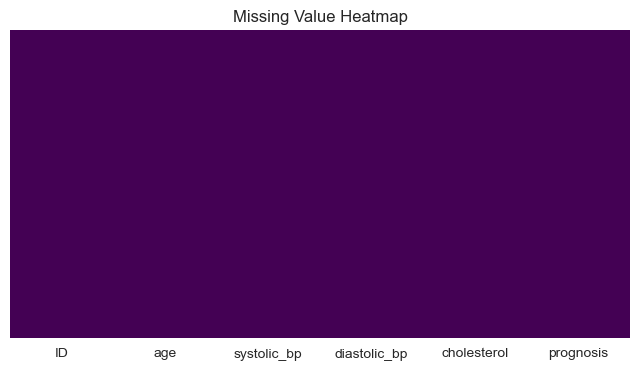

In [9]:
# Missing Value Analysis

missing = pd.DataFrame({

    "Missing Values": df.isnull().sum(),

    "Percentage (%)": round((df.isnull().sum()/len(df))*100,2)

})

display(missing)

plt.figure(figsize=(8,4))

sns.heatmap(
    df.isnull(),
    cmap="viridis",
    cbar=False,
    yticklabels=False
)

plt.title("Missing Value Heatmap")

plt.show() 

In [10]:
# Duplicate Analysis

duplicates = df.duplicated().sum()

print(f"Duplicate Records : {duplicates}")

print(f"Duplicate Percentage : {(duplicates/len(df))*100:.2f}%") 

Duplicate Records : 0
Duplicate Percentage : 0.00%


In [11]:
# Statistical Summary

summary = df.describe().T

summary["Median"] = df.median(numeric_only=True)

summary["Variance"] = df.var(numeric_only=True)

summary["Skewness"] = df.skew(numeric_only=True)

summary["Kurtosis"] = df.kurtosis(numeric_only=True)

display(summary) 

,count,mean,std,min,25%,50%,75%,max,Median,Variance,Skewness,Kurtosis
ID,6000.0,2999.500000,1732.195139,0.000000,1499.750000,2999.500000,4499.250000,5999.000000,2999.500000,3.000500e+06,0.000000,-1.200000
age,6000.0,60.464121,8.564392,35.164761,54.371941,59.831159,65.809652,103.279497,59.831159,7.334881e+01,0.441141,0.275005
systolic_bp,6000.0,100.694822,10.669267,69.675429,93.267420,100.119926,107.439501,151.699660,100.119926,1.138333e+02,0.334655,0.212703
diastolic_bp,6000.0,90.505547,9.648200,62.807105,83.641788,89.912429,96.682405,133.456382,89.912429,9.308776e+01,0.336555,0.162188
cholesterol,6000.0,100.628255,10.433915,69.967453,93.202373,100.060637,107.250829,148.233544,100.060637,1.088666e+02,0.361514,0.259594


In [12]:
# Unique Values

unique = pd.DataFrame({

    "Feature": df.columns,

    "Unique Values": df.nunique().values

})

display(unique) 

,Feature,Unique Values
0,ID,6000
1,age,6000
2,systolic_bp,6000
3,diastolic_bp,6000
4,cholesterol,6000
5,prognosis,2


In [13]:
# ID Validation

print("Is ID Unique :", df["ID"].is_unique)

print("Minimum ID :", df["ID"].min())

print("Maximum ID :", df["ID"].max()) 

Is ID Unique : True
Minimum ID : 0
Maximum ID : 5999


In [14]:
# Invalid Value Check

print("Negative Age :", (df["age"] < 0).sum())

print("Negative Systolic BP :", (df["systolic_bp"] < 0).sum())

print("Negative Diastolic BP :", (df["diastolic_bp"] < 0).sum())

print("Negative Cholesterol :", (df["cholesterol"] < 0).sum()) 

Negative Age : 0
Negative Systolic BP : 0
Negative Diastolic BP : 0
Negative Cholesterol : 0


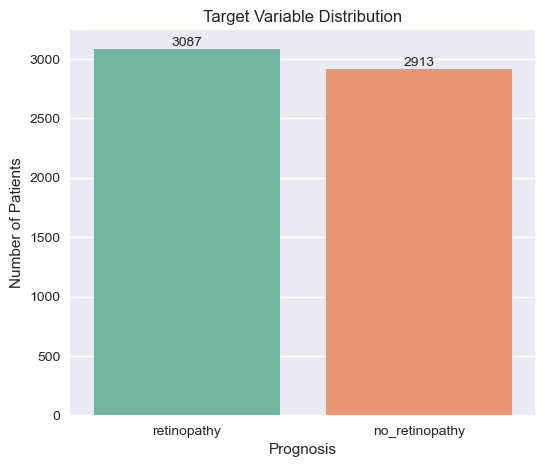

,Count,Percentage (%)
prognosis,,
retinopathy,3087,51.45
no_retinopathy,2913,48.55


In [15]:
# Target Variable Distribution

plt.figure(figsize=(6,5))

ax = sns.countplot(
    data=df,
    x="prognosis",
    palette="Set2"
)

for container in ax.containers:
    ax.bar_label(container)

plt.title("Target Variable Distribution")
plt.xlabel("Prognosis")
plt.ylabel("Number of Patients")

plt.show()

display(
    pd.DataFrame({
        "Count": df["prognosis"].value_counts(),
        "Percentage (%)": round(df["prognosis"].value_counts(normalize=True)*100,2)
    })
) 

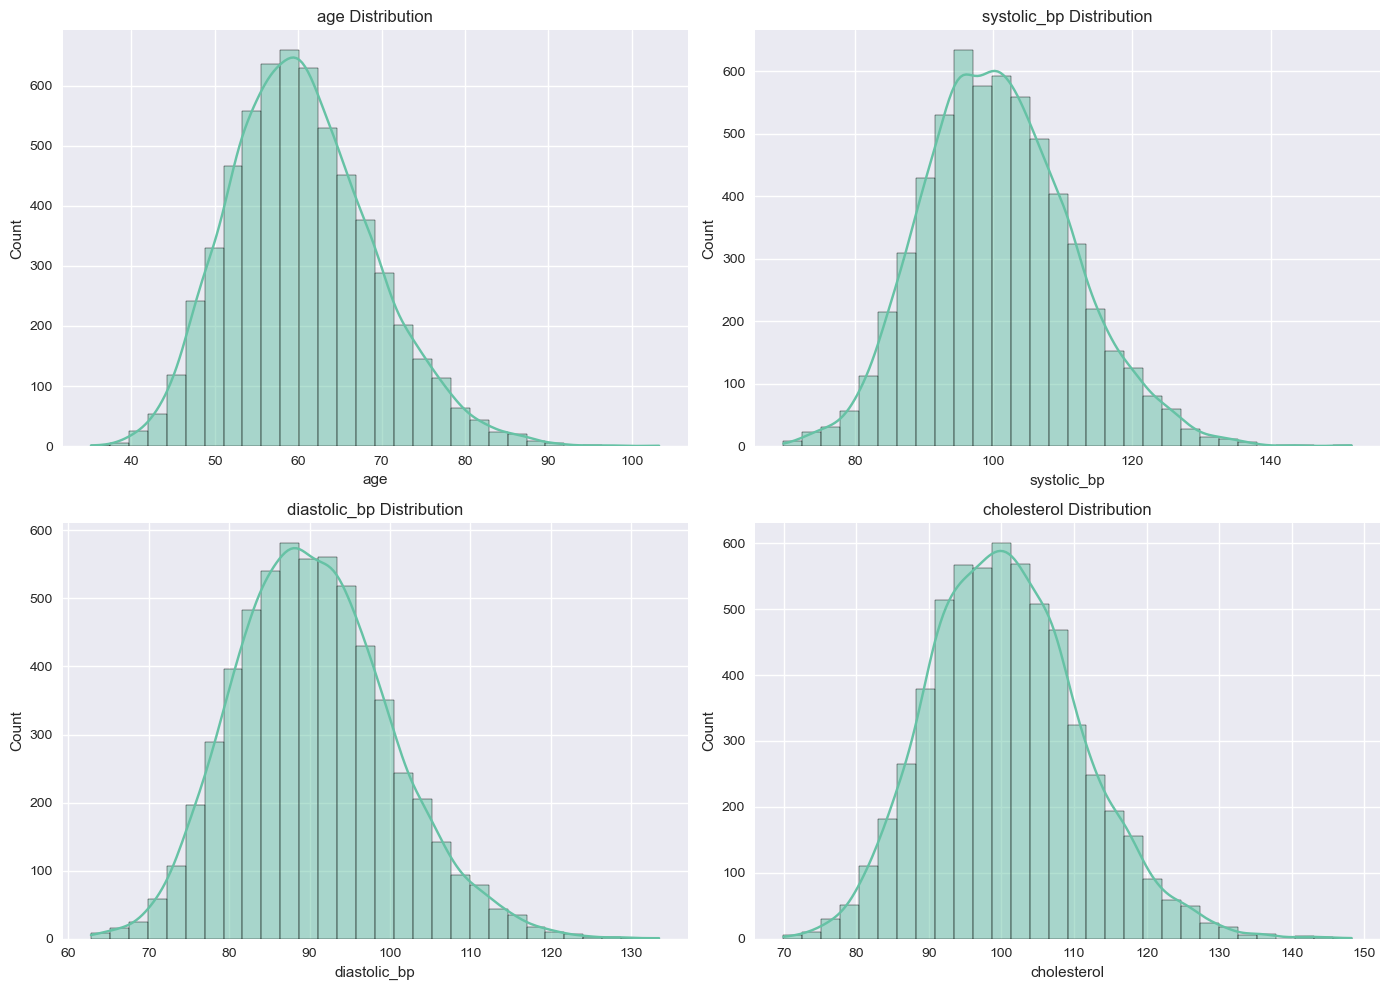

In [16]:
# Distribution of Numerical Features

numerical_columns = [
    "age",
    "systolic_bp",
    "diastolic_bp",
    "cholesterol"
]

fig, axes = plt.subplots(2,2,figsize=(14,10))

for ax, column in zip(axes.flatten(), numerical_columns):

    sns.histplot(
        df[column],
        kde=True,
        bins=30,
        ax=ax
    )

    ax.set_title(f"{column} Distribution")

plt.tight_layout()

plt.show() 

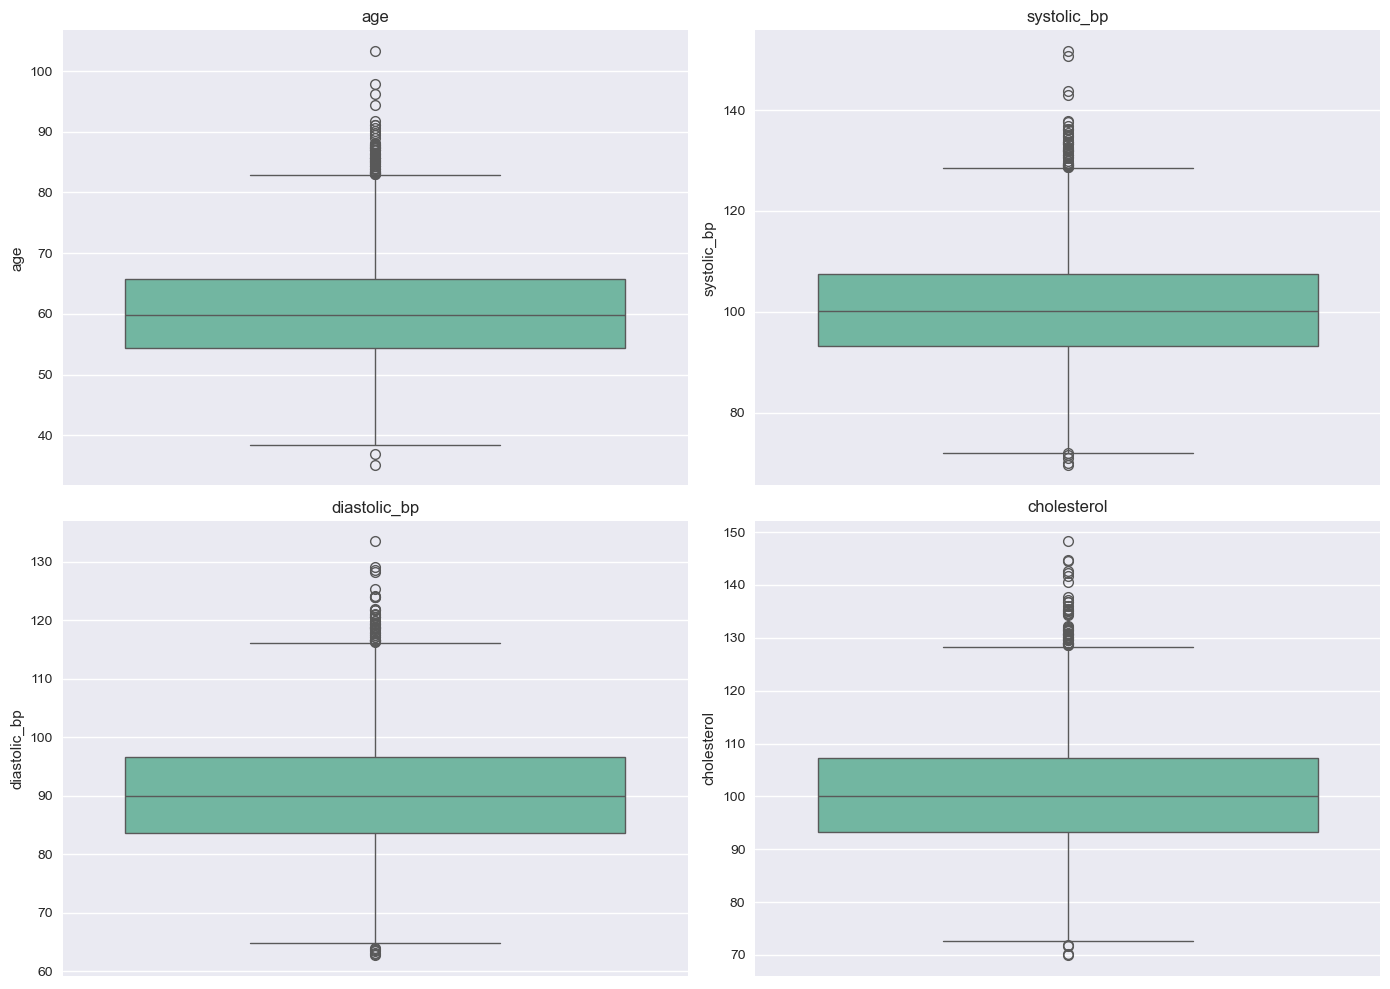

In [17]:
# Boxplots

fig, axes = plt.subplots(2,2,figsize=(14,10))

for ax, column in zip(axes.flatten(), numerical_columns):

    sns.boxplot(
        y=df[column],
        ax=ax
    )

    ax.set_title(column)

plt.tight_layout()

plt.show() 

In [18]:
# Outlier Analysis

outlier_summary = []

for column in numerical_columns:

    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)

    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    outliers = df[(df[column] < lower) | (df[column] > upper)]

    outlier_summary.append({

        "Feature": column,
        "Outliers": len(outliers),
        "Percentage (%)": round(len(outliers)/len(df)*100,2)

    })

display(pd.DataFrame(outlier_summary))

,Feature,Outliers,Percentage (%)
0,age,65,1.08
1,systolic_bp,55,0.92
2,diastolic_bp,55,0.92
3,cholesterol,54,0.90


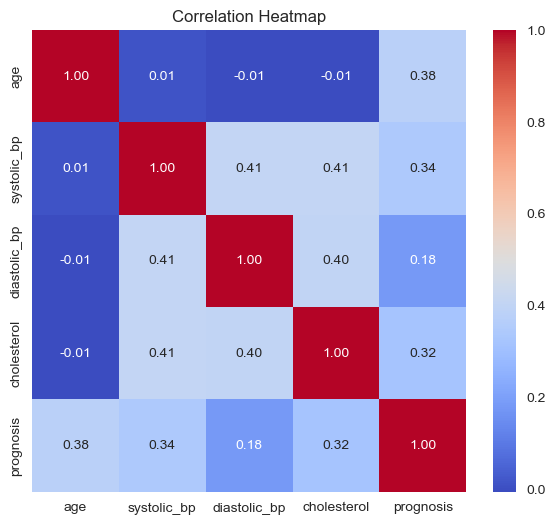

In [19]:
# Correlation Heatmap

corr_df = df.drop(columns=["ID"])

corr_df["prognosis"] = corr_df["prognosis"].map({
    "no_retinopathy":0,
    "retinopathy":1
})

plt.figure(figsize=(7,6))

sns.heatmap(
    corr_df.corr(),
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Heatmap")

plt.show() 

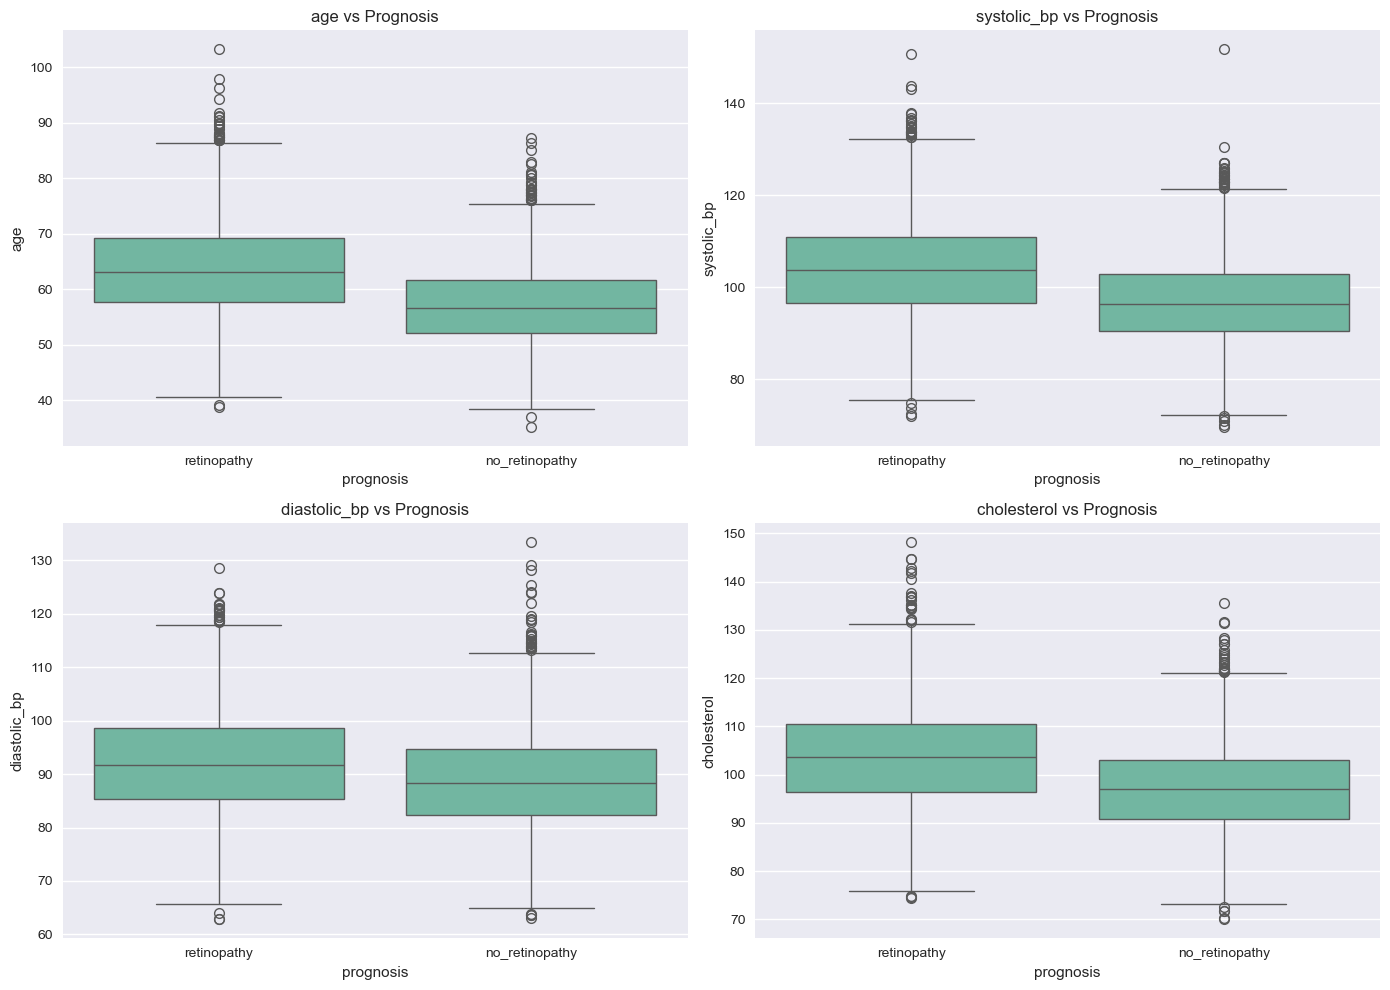

In [20]:
# Feature-wise Comparison

fig, axes = plt.subplots(2,2,figsize=(14,10))

for ax, column in zip(axes.flatten(), numerical_columns):

    sns.boxplot(
        data=df,
        x="prognosis",
        y=column,
        ax=ax
    )

    ax.set_title(f"{column} vs Prognosis")

plt.tight_layout()

plt.show() 

In [21]:
# EDA Summary

print("="*60)
print("EDA SUMMARY")
print("="*60)

print("""
• The dataset contains 6,000 patient records with 6 features.

• No missing values were found.

• No duplicate records were detected.

• All patient IDs are unique.

• No invalid negative values were observed in the numerical features.

• The target variable consists of two classes:
  - Retinopathy
  - No Retinopathy

• The dataset is nearly balanced, making it suitable for binary classification.

• Outlier analysis shows a few extreme values in some clinical features.

• Correlation analysis indicates relationships among age, blood pressure, and cholesterol.

• The dataset is clean and ready for preprocessing and machine learning.
""") 

EDA SUMMARY

• The dataset contains 6,000 patient records with 6 features.

• No missing values were found.

• No duplicate records were detected.

• All patient IDs are unique.

• No invalid negative values were observed in the numerical features.

• The target variable consists of two classes:
  - Retinopathy
  - No Retinopathy

• The dataset is nearly balanced, making it suitable for binary classification.

• Outlier analysis shows a few extreme values in some clinical features.

• Correlation analysis indicates relationships among age, blood pressure, and cholesterol.

• The dataset is clean and ready for preprocessing and machine learning.



##### Preprocessing

In [22]:
# Remove ID Column

df = df.drop("ID", axis=1)

display(df.head()) 

,age,systolic_bp,diastolic_bp,cholesterol,prognosis
0,77.196340,85.288742,80.021878,79.957109,retinopathy
1,63.529850,99.379736,84.852361,110.382411,retinopathy
2,69.003986,111.349455,109.850616,100.828246,retinopathy
3,82.638210,95.056128,79.666851,87.066303,retinopathy
4,78.346286,109.154591,90.713220,92.511770,retinopathy


In [23]:
# Encode Target Variable

from sklearn.preprocessing import LabelEncoder

label_encoder = LabelEncoder()

df["prognosis"] = label_encoder.fit_transform(df["prognosis"])

display(df.head()) 

,age,systolic_bp,diastolic_bp,cholesterol,prognosis
0,77.196340,85.288742,80.021878,79.957109,1
1,63.529850,99.379736,84.852361,110.382411,1
2,69.003986,111.349455,109.850616,100.828246,1
3,82.638210,95.056128,79.666851,87.066303,1
4,78.346286,109.154591,90.713220,92.511770,1


In [24]:
# Separate Features and Target

X = df.drop("prognosis", axis=1)

y = df["prognosis"]

print("Feature Matrix Shape :", X.shape)
print("Target Vector Shape :", y.shape) 

Feature Matrix Shape : (6000, 4)
Target Vector Shape : (6000,)


In [25]:
# Train-Test Split

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training Samples :", X_train.shape[0])
print("Testing Samples :", X_test.shape[0]) 

Training Samples : 4800
Testing Samples : 1200


In [26]:
# Feature Scaling

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)

X_test_scaled = scaler.transform(X_test) 

In [27]:
# Convert Scaled Data to DataFrame

X_train_scaled = pd.DataFrame(
    X_train_scaled,
    columns=X.columns
)

X_test_scaled = pd.DataFrame(
    X_test_scaled,
    columns=X.columns
)

display(X_train_scaled.head()) 

,age,systolic_bp,diastolic_bp,cholesterol
0,-0.672058,-1.800758,-0.342535,-0.772973
1,-1.131315,0.125457,0.528409,0.450204
2,-0.710883,0.185262,-0.758167,-1.706528
3,-0.938105,0.458424,0.165243,-1.046507
4,0.537810,2.527141,1.158744,0.834273


In [28]:
# Verify Preprocessed Data

print("Training Feature Shape :", X_train_scaled.shape)
print("Testing Feature Shape :", X_test_scaled.shape)

print("\nTraining Target Distribution")
print(y_train.value_counts())

print("\nTesting Target Distribution")
print(y_test.value_counts()) 

Training Feature Shape : (4800, 4)
Testing Feature Shape : (1200, 4)

Training Target Distribution
prognosis
1    2470
0    2330
Name: count, dtype: int64

Testing Target Distribution
prognosis
1    617
0    583
Name: count, dtype: int64


#### Model Building

In [29]:
# Import Model Libraries

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
) 

In [30]:
# Initialize Models

models = {
    "Logistic Regression": LogisticRegression(random_state=42),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(random_state=42),
    "KNN": KNeighborsClassifier(),
    "SVM": SVC(probability=True, random_state=42)
} 

In [31]:
# Train and Evaluate Models

results = []

trained_models = {}

for name, model in models.items():

    # Use scaled data for scale-sensitive models
    if name in ["Logistic Regression", "KNN", "SVM"]:

        model.fit(X_train_scaled, y_train)

        y_pred = model.predict(X_test_scaled)

        y_prob = model.predict_proba(X_test_scaled)[:, 1]

    # Use original data for tree-based models
    else:

        model.fit(X_train, y_train)

        y_pred = model.predict(X_test)

        y_prob = model.predict_proba(X_test)[:, 1]

    trained_models[name] = model

    results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1 Score": f1_score(y_test, y_pred),
        "ROC-AUC": roc_auc_score(y_test, y_prob)
    }) 

#### Model Building and Model Evaluation

In [32]:
# Import Model Libraries

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
) 

In [33]:
# Initialize Models

models = {
    "Logistic Regression": LogisticRegression(random_state=42),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(random_state=42),
    "KNN": KNeighborsClassifier(),
    "SVM": SVC(probability=True, random_state=42)
} 

In [34]:
# Train and Evaluate Models

results = []

trained_models = {}

for name, model in models.items():

    # Use scaled data for scale-sensitive models
    if name in ["Logistic Regression", "KNN", "SVM"]:

        model.fit(X_train_scaled, y_train)

        y_pred = model.predict(X_test_scaled)

        y_prob = model.predict_proba(X_test_scaled)[:, 1]

    # Use original data for tree-based models
    else:

        model.fit(X_train, y_train)

        y_pred = model.predict(X_test)

        y_prob = model.predict_proba(X_test)[:, 1]

    trained_models[name] = model

    results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1 Score": f1_score(y_test, y_pred),
        "ROC-AUC": roc_auc_score(y_test, y_prob)
    }) 

In [35]:
# Model Comparison

results_df = pd.DataFrame(results)

results_df = results_df.sort_values(
    by="F1 Score",
    ascending=False
).reset_index(drop=True)

display(
    results_df.style.format({
        "Accuracy": "{:.4f}",
        "Precision": "{:.4f}",
        "Recall": "{:.4f}",
        "F1 Score": "{:.4f}",
        "ROC-AUC": "{:.4f}"
    })
) 

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,SVM,0.7708,0.7714,0.7877,0.7795,0.8348
1,Logistic Regression,0.7675,0.7864,0.7520,0.7688,0.8415
2,KNN,0.7300,0.7382,0.7358,0.7370,0.7888
3,Random Forest,0.7275,0.7324,0.7407,0.7365,0.8134
4,Decision Tree,0.6800,0.6998,0.6613,0.6800,0.6805


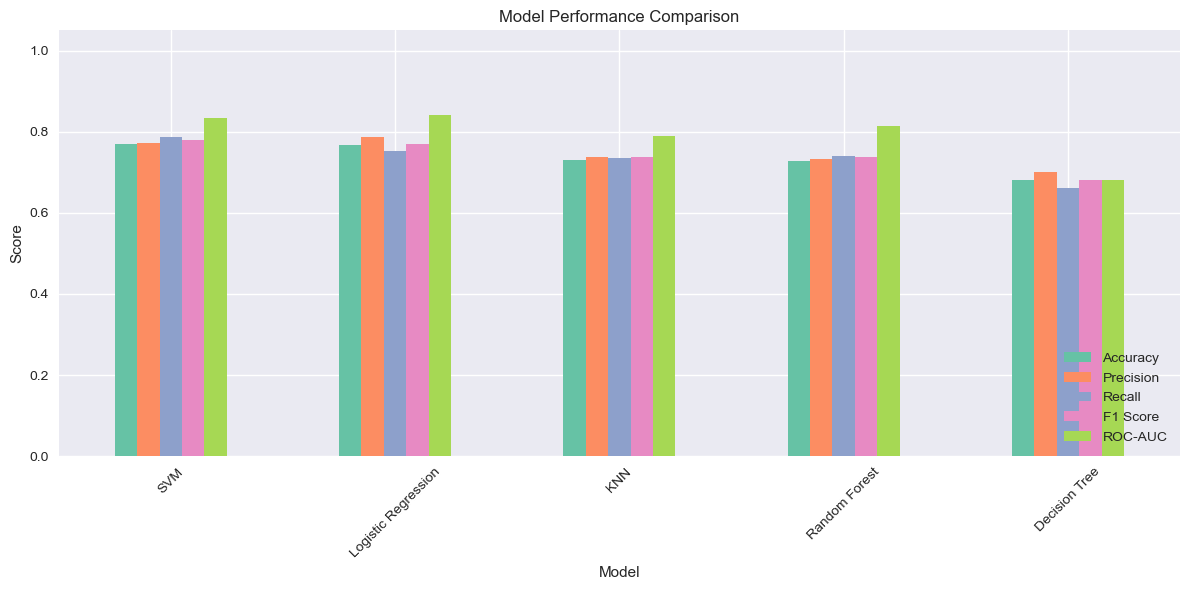

In [36]:
# Model Performance Comparison

comparison_df = results_df.set_index("Model")

comparison_df.plot(
    kind="bar",
    figsize=(12,6)
)

plt.title("Model Performance Comparison")
plt.xlabel("Model")
plt.ylabel("Score")
plt.ylim(0,1.05)
plt.xticks(rotation=45)
plt.legend(loc="lower right")

plt.tight_layout()

plt.show() 

In [37]:
# Import XGBoost

from xgboost import XGBClassifier

In [38]:
# Build and Train XGBoost Model

xgb_model = XGBClassifier(
    random_state=42,
    eval_metric="logloss"
)

xgb_model.fit(X_train, y_train) 

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=None, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=None, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=None, n_jobs=None,
              num_parallel_tree=None, ...)

In [39]:
# XGBoost Prediction and Evaluation

xgb_pred = xgb_model.predict(X_test)

xgb_prob = xgb_model.predict_proba(X_test)[:, 1]

xgb_accuracy = accuracy_score(y_test, xgb_pred)
xgb_precision = precision_score(y_test, xgb_pred)
xgb_recall = recall_score(y_test, xgb_pred)
xgb_f1 = f1_score(y_test, xgb_pred)
xgb_roc_auc = roc_auc_score(y_test, xgb_prob)

print(f"Accuracy  : {xgb_accuracy:.4f}")
print(f"Precision : {xgb_precision:.4f}")
print(f"Recall    : {xgb_recall:.4f}")
print(f"F1 Score  : {xgb_f1:.4f}")
print(f"ROC-AUC   : {xgb_roc_auc:.4f}") 

Accuracy  : 0.7417
Precision : 0.7480
Recall    : 0.7504
F1 Score  : 0.7492
ROC-AUC   : 0.8088


In [40]:
# Add XGBoost Results

xgb_result = pd.DataFrame({
    "Model": ["XGBoost"],
    "Accuracy": [xgb_accuracy],
    "Precision": [xgb_precision],
    "Recall": [xgb_recall],
    "F1 Score": [xgb_f1],
    "ROC-AUC": [xgb_roc_auc]
})

final_results_df = pd.concat(
    [results_df, xgb_result],
    ignore_index=True
)

final_results_df = final_results_df.sort_values(
    by="F1 Score",
    ascending=False
).reset_index(drop=True)

display(
    final_results_df.style.format({
        "Accuracy": "{:.4f}",
        "Precision": "{:.4f}",
        "Recall": "{:.4f}",
        "F1 Score": "{:.4f}",
        "ROC-AUC": "{:.4f}"
    })
) 

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,SVM,0.7708,0.7714,0.7877,0.7795,0.8348
1,Logistic Regression,0.7675,0.7864,0.7520,0.7688,0.8415
2,XGBoost,0.7417,0.7480,0.7504,0.7492,0.8088
3,KNN,0.7300,0.7382,0.7358,0.7370,0.7888
4,Random Forest,0.7275,0.7324,0.7407,0.7365,0.8134
5,Decision Tree,0.6800,0.6998,0.6613,0.6800,0.6805


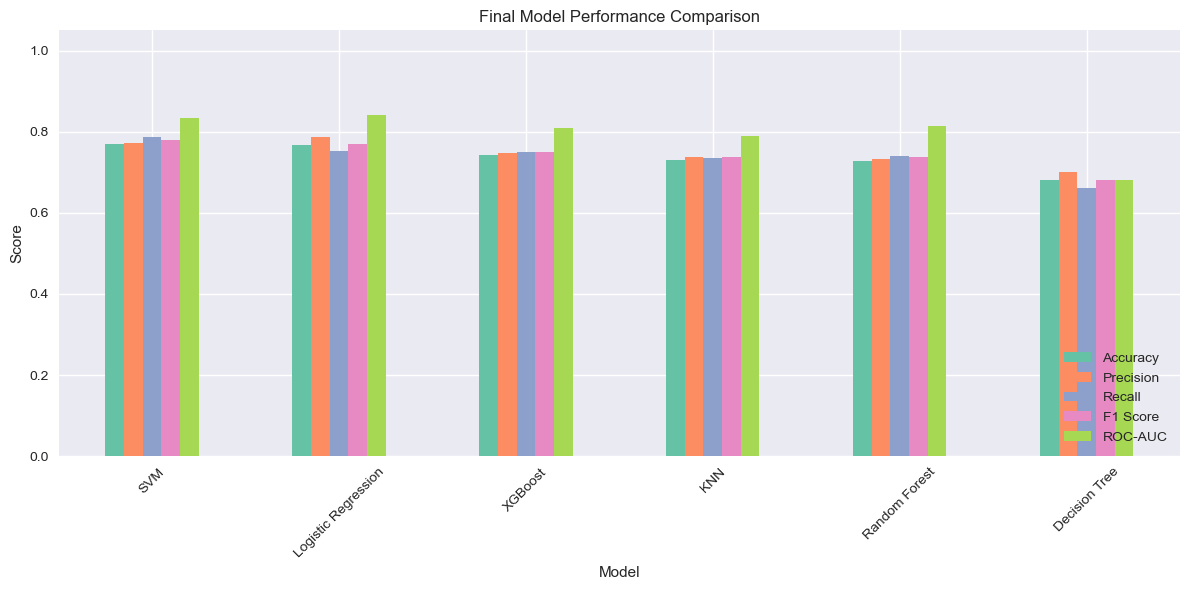

In [41]:
# Final Model Performance Comparison

final_comparison = final_results_df.set_index("Model")

final_comparison.plot(
    kind="bar",
    figsize=(12, 6)
)

plt.title("Final Model Performance Comparison")
plt.xlabel("Model")
plt.ylabel("Score")
plt.ylim(0, 1.05)
plt.xticks(rotation=45)
plt.legend(loc="lower right")

plt.tight_layout()

plt.show() 

SVM was selected as the final model because it achieved the highest Accuracy (77.08%), Recall (78.77%), and F1 Score (77.95%) among the evaluated models. Its higher Recall is particularly valuable for identifying patients with diabetic retinopathy and reducing false negatives. Overall, SVM provided the best balance of classification performance for this dataset. 

In [42]:
# Check SVM Training and Testing Performance

svm_model = trained_models["SVM"]

train_pred = svm_model.predict(X_train_scaled)
test_pred = svm_model.predict(X_test_scaled)

train_accuracy = accuracy_score(y_train, train_pred)
test_accuracy = accuracy_score(y_test, test_pred)

print(f"Training Accuracy : {train_accuracy:.4f}")
print(f"Testing Accuracy  : {test_accuracy:.4f}")
print(f"Accuracy Difference : {train_accuracy - test_accuracy:.4f}") 

Training Accuracy : 0.7506
Testing Accuracy  : 0.7708
Accuracy Difference : -0.0202


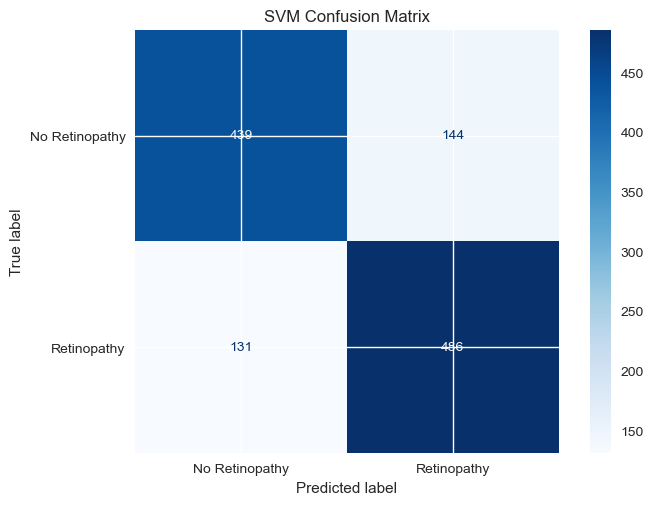

In [43]:
# SVM Confusion Matrix

from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(y_test, test_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["No Retinopathy", "Retinopathy"]
)

disp.plot(cmap="Blues")

plt.title("SVM Confusion Matrix")
plt.show() 

In [44]:
# SVM Classification Report

from sklearn.metrics import classification_report

print(
    classification_report(
        y_test,
        test_pred,
        target_names=["No Retinopathy", "Retinopathy"]
    )
) 

                precision    recall  f1-score   support

No Retinopathy       0.77      0.75      0.76       583
   Retinopathy       0.77      0.79      0.78       617

      accuracy                           0.77      1200
     macro avg       0.77      0.77      0.77      1200
  weighted avg       0.77      0.77      0.77      1200



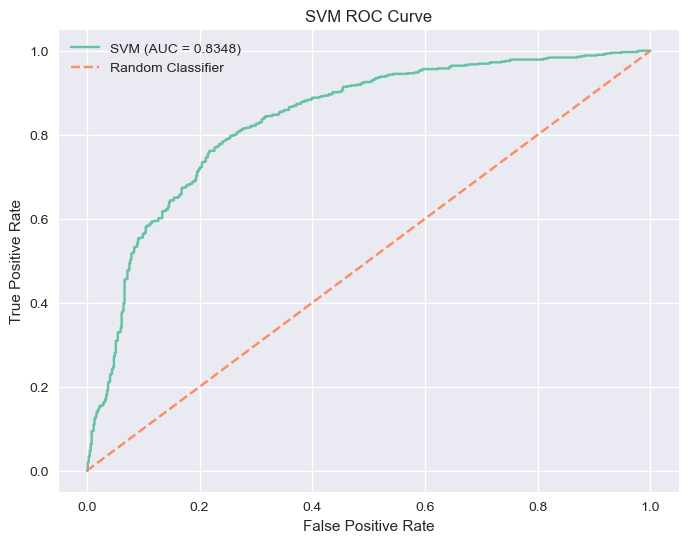

In [45]:
# SVM ROC Curve

from sklearn.metrics import roc_curve, auc

svm_prob = svm_model.predict_proba(X_test_scaled)[:, 1]

fpr, tpr, thresholds = roc_curve(y_test, svm_prob)

roc_auc = auc(fpr, tpr)

plt.figure(figsize=(8, 6))

plt.plot(
    fpr,
    tpr,
    label=f"SVM (AUC = {roc_auc:.4f})"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Random Classifier"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("SVM ROC Curve")
plt.legend()

plt.show() 

In [46]:
# Final SVM Model Performance

svm_accuracy = accuracy_score(y_test, test_pred)
svm_precision = precision_score(y_test, test_pred)
svm_recall = recall_score(y_test, test_pred)
svm_f1 = f1_score(y_test, test_pred)
svm_auc = roc_auc_score(y_test, svm_prob)

print("Final Model: Support Vector Machine (SVM)")
print(f"Accuracy  : {svm_accuracy:.4f}")
print(f"Precision : {svm_precision:.4f}")
print(f"Recall    : {svm_recall:.4f}")
print(f"F1 Score  : {svm_f1:.4f}")
print(f"ROC-AUC   : {svm_auc:.4f}") 

Final Model: Support Vector Machine (SVM)
Accuracy  : 0.7708
Precision : 0.7714
Recall    : 0.7877
F1 Score  : 0.7795
ROC-AUC   : 0.8348


## Final Model Selection

After evaluating Logistic Regression, Decision Tree, Random Forest, K-Nearest Neighbors (KNN), Support Vector Machine (SVM), and XGBoost, SVM was selected as the final model.

SVM achieved the highest overall performance with an accuracy of 77.08%, recall of 78.77%, and F1-score of 77.95%. It also achieved a ROC-AUC score of 83.48%, indicating good ability to distinguish between patients with and without diabetic retinopathy.

Although Logistic Regression achieved a slightly higher ROC-AUC score of 84.15% and higher precision, SVM provided the highest recall and F1-score. The higher recall is particularly valuable for identifying retinopathy cases and reducing missed positive cases.

The training accuracy was 75.06% and the testing accuracy was 77.08%, showing no evidence of overfitting based on the observed accuracy gap. Therefore, SVM was selected as the final model for this project.

## Model Evaluation Summary

The final SVM model achieved the following performance:

- Accuracy: 77.08%
- Precision: 77.14%
- Recall: 78.77%
- F1-Score: 77.95%
- ROC-AUC: 83.48%

The confusion matrix showed:

- 439 patients without retinopathy were correctly classified.
- 486 patients with retinopathy were correctly classified.
- 144 patients without retinopathy were incorrectly classified as having retinopathy.
- 131 patients with retinopathy were incorrectly classified as not having retinopathy.

Overall, the SVM model demonstrated balanced classification performance and good discriminative ability. Among the models evaluated, it provided the strongest overall combination of accuracy, recall, and F1-score.

In [47]:
# Save Final Model and Scaler

import joblib

joblib.dump(svm_model, "svm_retinopathy_model.pkl")

joblib.dump(scaler, "scaler.pkl")

print("SVM model and scaler saved successfully.")

SVM model and scaler saved successfully.
